<a href="https://colab.research.google.com/github/SanaAfia/API-Agent/blob/main/LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
import subprocess
import os
os.environ["KERAS_BACKEND"] = "torch"
required_packages = {
    "sklearn": "scikit-learn",
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "joblib": "joblib",
    "yfinance": "yfinance",
    "keras": "keras",
    "torch": "torch"
}
for mod, pkg in required_packages.items():
    try:
        __import__(mod)
    except ImportError:
        print(f"Installing missing package: {pkg}...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
        except Exception as e:
            print(f"Warning: Failed to install {pkg}: {e}")

In [ ]:
import os
import glob
import zipfile
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
try:
    from IPython.display import display
except ImportError:
    display = print
# Try importing tensorflow/keras, fallback to standalone keras with torch backend
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except ImportError:
    os.environ["KERAS_BACKEND"] = "torch"
    import keras
    from keras import layers
    import types
    tf = types.SimpleNamespace(
        __version__="Keras (" + keras.__version__ + ")",
        config=types.SimpleNamespace(list_physical_devices=lambda x: [])
    )
SEED = 42
np.random.seed(SEED)
print("TensorFlow/Keras loaded successfully.")
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow/Keras loaded successfully.
GPU available: []


In [ ]:
DATA_ROOT = "."
search_roots = ["/content", "/content/stock_market_dataset", DATA_ROOT]
all_data_files = []
for root in search_roots:
    if os.path.exists(root):
        all_data_files.extend(glob.glob(os.path.join(root, "**", "*.csv"), recursive=True))
        all_data_files.extend(glob.glob(os.path.join(root, "**", "*.txt"), recursive=True))
all_data_files = sorted(set(all_data_files))
stock_like_files = []
ignored_names = {"sample_submission.csv", "train.csv", "test.csv", "all_cells.txt", "requirements.txt"}
for file in all_data_files:
    name = os.path.basename(file).lower()
    if name not in ignored_names and not name.endswith(".py") and not name.startswith("verify_") and not name.startswith("run_"):
        try:
            sample_df = pd.read_csv(file, nrows=2)
            if "Close" in sample_df.columns or "close" in sample_df.columns:
                stock_like_files.append(file)
        except Exception:
            pass
dataset_files = stock_like_files
# Fallback: If no valid stock CSV/TXT files exist, download AAPL via yfinance or create dummy CSV
if not dataset_files:
    print("No local stock CSV/TXT files found. Fetching AAPL stock data via yfinance...")
    try:
        import yfinance as yf
        df_aapl = yf.download("AAPL", start="2018-01-01", end="2024-01-01")
        df_aapl.reset_index(inplace=True)
        if isinstance(df_aapl.columns, pd.MultiIndex):
            df_aapl.columns = [col[0] for col in df_aapl.columns]
        aapl_path = os.path.abspath("aapl.csv")
        df_aapl.to_csv(aapl_path, index=False)
        dataset_files = [aapl_path]
        print(f"Downloaded and saved fallback dataset: {aapl_path}")
    except Exception as e:
        print("yfinance download failed, creating synthetic stock dataset...", e)
        dates = pd.date_range(start="2018-01-01", periods=1000, freq="B")
        np.random.seed(42)
        price = 100.0 + np.cumsum(np.random.randn(1000))
        df_synth = pd.DataFrame({
            "Date": dates,
            "Open": price + np.random.randn(1000)*0.5,
            "High": price + np.abs(np.random.randn(1000)),
            "Low": price - np.abs(np.random.randn(1000)),
            "Close": price,
            "Volume": np.random.randint(1000000, 5000000, size=1000)
        })
        synth_path = os.path.abspath("aapl.csv")
        df_synth.to_csv(synth_path, index=False)
        dataset_files = [synth_path]
        print(f"Saved synthetic dataset: {synth_path}")
print(f"Data files found: {len(dataset_files)}")
for file in dataset_files[:30]:
    print(" -", file)

No local stock CSV/TXT files found. Fetching AAPL stock data via yfinance...


[*********************100%***********************]  1 of 1 completed

Downloaded and saved fallback dataset: /content/aapl.csv
Data files found: 1
 - /content/aapl.csv


In [ ]:
TICKER = "AAPL"  # Change this to another ticker if needed
def find_ticker_file(ticker, files):
    ticker = ticker.lower().strip()
    exact_matches = []
    possible_matches = []
    for file in files:
        name = os.path.basename(file).lower()
        stem = os.path.splitext(name)[0]
        if stem == ticker or stem == f"{ticker}.us":
            exact_matches.append(file)
        elif name.startswith(ticker + ".") or name.startswith(ticker + "_"):
            possible_matches.append(file)
    if exact_matches:
        return sorted(exact_matches)
    return sorted(possible_matches)
ticker_files = find_ticker_file(TICKER, dataset_files)
if not ticker_files and dataset_files:
    ticker_files = dataset_files
print("=" * 60)
print(f"SEARCHING FOR: {TICKER.upper()}")
print("=" * 60)
if ticker_files:
    for i, file in enumerate(ticker_files, start=1):
        print(f"{i}. {file}")
    ticker_file = ticker_files[0]
    print()
    print("SELECTED FILE:")
    print(ticker_file)
else:
    ticker_file = None
    print(f"No file found for '{TICKER}'.")
    print()
    print("Example available files:")
    for file in dataset_files[:30]:
        print(" -", file)

SEARCHING FOR: AAPL
1. /content/aapl.csv

SELECTED FILE:
/content/aapl.csv


In [ ]:
df = pd.read_csv(ticker_file)
print("Shape:", df.shape)
display(df.head())
display(df.tail())
print("\nData types:")
print(df.dtypes)

Shape: (1509, 6)


,Date,Close,High,Low,Open,Volume
0,2018-01-02,40.232388,40.241732,39.531719,39.741922,102223600
1,2018-01-03,40.225372,40.767224,40.162315,40.295440,118071600
2,2018-01-04,40.412212,40.514978,40.190335,40.297769,89738400
3,2018-01-05,40.872326,40.958741,40.416892,40.507979,94640000
4,2018-01-08,40.720516,41.014796,40.622419,40.720516,82271200


,Date,Close,High,Low,Open,Volume
1504,2023-12-22,191.268143,193.056339,190.645726,192.829099,37149600
1505,2023-12-26,190.724762,191.554641,190.507411,191.278014,28919300
1506,2023-12-27,190.823532,191.169322,188.788347,190.171493,48087700
1507,2023-12-28,191.248352,192.315345,190.843287,191.801605,34049900
1508,2023-12-29,190.211014,192.058485,189.420647,191.564508,42672100



Data types:
Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [ ]:
required_cols = ["Date", "Open", "High", "Low", "Close", "Volume"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(
        f"Missing required columns: {missing_cols}\n"
        f"Found columns: {list(df.columns)}"
    )
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
numeric_cols = ["Open", "High", "Low", "Close", "Volume"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
# Remove invalid observations, duplicate dates, and sort chronologically.
df = (
    df.dropna(subset=required_cols)
      .drop_duplicates(subset=["Date"])
      .sort_values("Date")
      .reset_index(drop=True)
)
if len(df) < 150:
    raise ValueError(
        f"Only {len(df)} valid rows remain. The workshop needs at least "
        "150 observations for a meaningful 60-day sequence experiment."
    )
print("Clean shape:", df.shape)
print("Date range:", df["Date"].min().date(), "→", df["Date"].max().date())
print("Missing values:")
print(df[numeric_cols].isna().sum())
display(df.head())

Clean shape: (1509, 6)
Date range: 2018-01-02 → 2023-12-29
Missing values:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


,Date,Close,High,Low,Open,Volume
0,2018-01-02,40.232388,40.241732,39.531719,39.741922,102223600
1,2018-01-03,40.225372,40.767224,40.162315,40.295440,118071600
2,2018-01-04,40.412212,40.514978,40.190335,40.297769,89738400
3,2018-01-05,40.872326,40.958741,40.416892,40.507979,94640000
4,2018-01-08,40.720516,41.014796,40.622419,40.720516,82271200


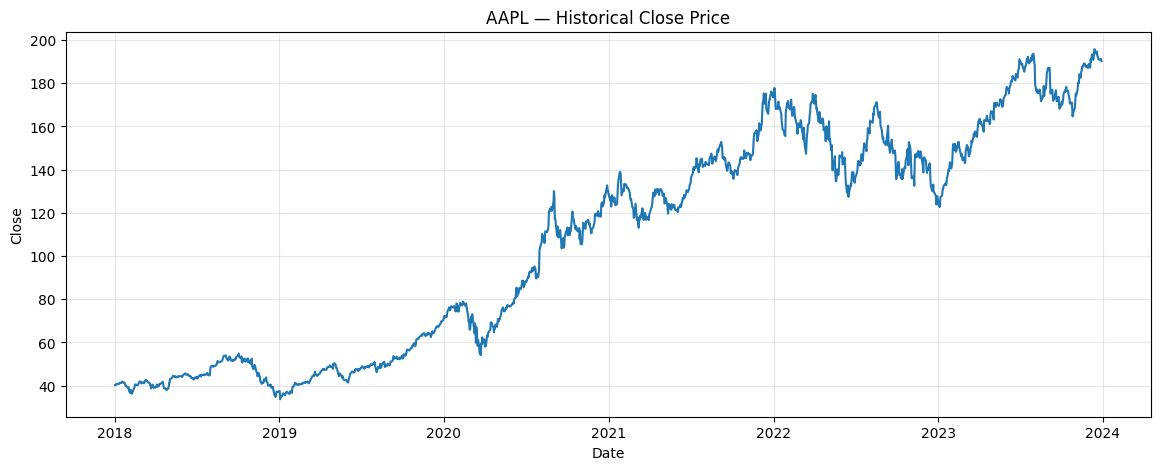

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Close"])
plt.title(f"{TICKER.upper()} — Historical Close Price")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True, alpha=0.3)
plt.show()

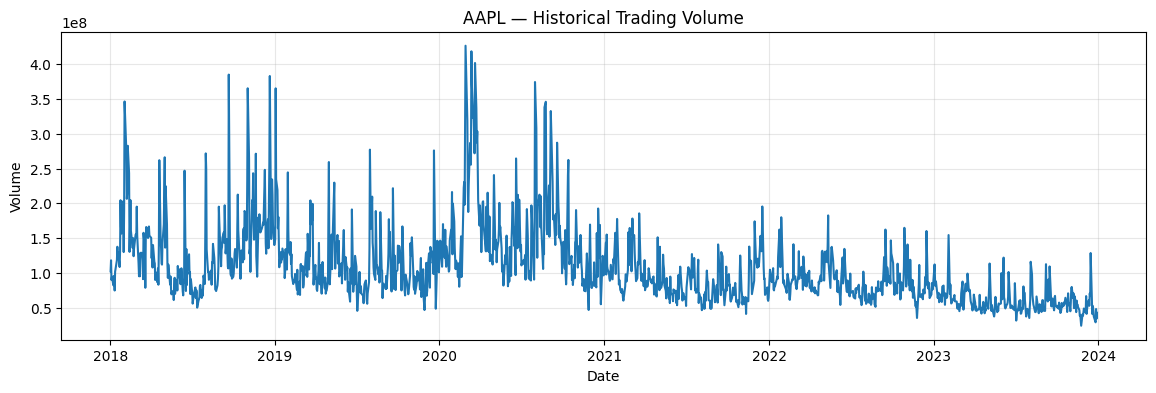

,count,mean,std,min,25%,50%,75%,max
Open,1509.0,1.074320e+02,5.075497e+01,3.413225e+01,5.123537e+01,1.202781e+02,1.496390e+02,1.956349e+02
High,1509.0,1.086563e+02,5.126835e+01,3.454474e+01,5.189919e+01,1.213884e+02,1.515599e+02,1.972156e+02
Low,1509.0,1.062949e+02,5.026972e+01,3.366287e+01,5.072036e+01,1.186427e+02,1.478209e+02,1.946272e+02
Close,1509.0,1.075317e+02,5.079583e+01,3.370791e+01,5.109834e+01,1.201377e+02,1.498130e+02,1.957238e+02
Volume,1509.0,1.073284e+08,5.513287e+07,2.404830e+07,7.078370e+07,9.296430e+07,1.280440e+08,4.265100e+08


In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(df["Date"], df["Volume"])
plt.title(f"{TICKER.upper()} — Historical Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True, alpha=0.3)
plt.show()
display(df[numeric_cols].describe().T)


In [ ]:
TRAIN_RATIO = 0.80
if len(df) < 150:
    raise ValueError("Not enough observations for the selected lookback and split.")
split_idx = int(len(df) * TRAIN_RATIO)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()
print("Training observations:", len(train_df))
print("Test observations: ", len(test_df))
print("Train period:", train_df["Date"].min().date(), "→", train_df["Date"].max().date())
print("Test period: ", test_df["Date"].min().date(), "→", test_df["Date"].max().date())

Training observations: 1207
Test observations:  302
Train period: 2018-01-02 → 2022-10-17
Test period:  2022-10-18 → 2023-12-29


In [ ]:
FEATURES = ["Open", "High", "Low", "Close", "Volume"]
TARGET = "Close"
LOOKBACK = 60
if len(train_df) <= LOOKBACK or len(test_df) == 0:
    raise ValueError(
        f"Not enough observations: train={len(train_df)}, test={len(test_df)}, "
        f"lookback={LOOKBACK}"
    )
train_raw = train_df[FEATURES].values.astype("float32")
test_raw = test_df[FEATURES].values.astype("float32")
print("Train raw shape:", train_raw.shape)
print("Test raw shape: ", test_raw.shape)

Train raw shape: (1207, 5)
Test raw shape:  (302, 5)


In [ ]:
feature_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = feature_scaler.fit_transform(train_raw)
target_scaler.fit(train_df[[TARGET]])
test_scaled = feature_scaler.transform(test_raw)
print("Scaled train range:", train_scaled.min(), "to", train_scaled.max())
print("Scaled test range:", test_scaled.min(), "to", test_scaled.max())

Scaled train range: 0.0 to 1.0000001
Scaled test range: -0.04397214 to 1.1391624


In [ ]:
def make_sequences(data_scaled, target_scaled, lookback):
    X, y = [], []
    if len(data_scaled) <= lookback:
        raise ValueError(f"Need more than {lookback} observations to create sequences.")
    for i in range(lookback, len(data_scaled)):
        X.append(data_scaled[i - lookback:i])
        y.append(target_scaled[i, 0])
    return (
        np.asarray(X, dtype="float32"),
        np.asarray(y, dtype="float32")
    )
# Training sequences
train_target_scaled = target_scaler.transform(train_df[[TARGET]]).astype("float32")
X_train, y_train = make_sequences(train_scaled, train_target_scaled, LOOKBACK)
# Test sequences use the last LOOKBACK training observations as historical context.
combined_df = pd.concat([train_df.tail(LOOKBACK), test_df], ignore_index=True)
combined_scaled = feature_scaler.transform(combined_df[FEATURES]).astype("float32")
combined_target_scaled = target_scaler.transform(combined_df[[TARGET]]).astype("float32")
X_test_full, y_test_full = make_sequences(combined_scaled, combined_target_scaled, LOOKBACK)
# The first LOOKBACK rows are training context; every resulting target here
# corresponds exactly to one observation in test_df.
X_test = X_test_full
y_test = y_test_full
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)
assert len(X_test) == len(test_df), (len(X_test), len(test_df))

X_train: (1147, 60, 5)
y_train: (1147,)
X_test:  (302, 60, 5)
y_test:  (302,)


In [ ]:
sample_id = 0
print("One input sequence shape:", X_train[sample_id].shape)
print("Target shape:", y_train[sample_id].shape)
sequence_preview = pd.DataFrame(X_train[sample_id], columns=FEATURES)
display(sequence_preview.head())
display(sequence_preview.tail())
print("Scaled target:", y_train[sample_id])

One input sequence shape: (60, 5)
Target shape: ()


,Open,High,Low,Close,Volume
0,0.038886,0.039521,0.041535,0.045284,0.158812
1,0.042723,0.043167,0.045997,0.045235,0.199921
2,0.042739,0.041417,0.046196,0.046532,0.126426
3,0.044196,0.044495,0.047799,0.049726,0.139140
4,0.045669,0.044884,0.049254,0.048672,0.107056


,Open,High,Low,Close,Volume
55,0.039749,0.041278,0.041580,0.040872,0.324150
56,0.037132,0.036787,0.035505,0.034508,0.319357
57,0.036612,0.041961,0.037995,0.047253,0.283170
58,0.045731,0.045296,0.038792,0.040042,0.318255
59,0.035279,0.036950,0.035920,0.037015,0.325994


Scaled target: 0.039130818


In [ ]:
# For each test day, predict that the next close equals the previous close.
naive_pred = test_df["Close"].shift(1).values.astype("float32")
# The first test observation uses the final training close.
naive_pred[0] = train_df["Close"].iloc[-1]
actual_test = test_df["Close"].values.astype("float32")
naive_mae = mean_absolute_error(actual_test, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(actual_test, naive_pred))
print(f"Naive MAE : ${naive_mae:.4f}")
print(f"Naive RMSE: ${naive_rmse:.4f}")

Naive MAE : $1.8108
Naive RMSE: $2.4311


In [ ]:
model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, len(FEATURES))),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.20),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,033 (78.25 KB)

 Trainable params: 20,033 (78.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 30
BATCH_SIZE = 32
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.10,
    shuffle=False,  # important for time-series training
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 217ms/step - loss: 0.0057 - mae: 0.0594 - val_loss: 0.0046 - val_mae: 0.0571
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step - loss: 0.0062 - mae: 0.0622 - val_loss: 0.0050 - val_mae: 0.0599
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - loss: 0.0063 - mae: 0.0653 - val_loss: 0.0014 - val_mae: 0.0309
Epoch 4/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - loss: 0.0020 - mae: 0.0306 - val_loss: 0.0015 - val_mae: 0.0319
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - loss: 0.0018 - mae: 0.0303 - val_loss: 0.0013 - val_mae: 0.0299
Epoch 6/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - loss: 0.0020 - mae: 0.0315 - val_loss: 0.0019 - val_mae: 0.0360
Epoch 7/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - loss: 0.0020 - mae: 0.0313 - val_loss: 0.0030 - val_mae: 0.0444
Epoch 8/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 141ms/step - loss: 0.0023 - mae: 0.0376 - val_loss: 0.0015 - val_mae: 0.0326
Epoch 9/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - lo

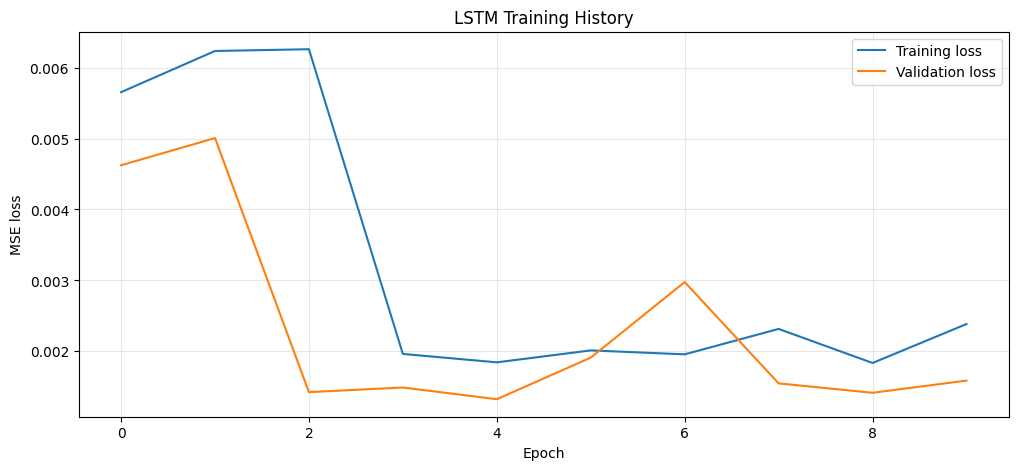

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("LSTM Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = target_scaler.inverse_transform(y_pred_scaled).ravel()
y_true = target_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100
# Previous close for each test day.
previous_close = test_df["Close"].shift(1).values.astype("float32")
previous_close[0] = train_df["Close"].iloc[-1]
actual_direction = np.sign(y_true - previous_close)
pred_direction = np.sign(y_pred - previous_close)
directional_accuracy = np.mean(actual_direction == pred_direction) * 100
print(f"LSTM MAE            : ${mae:.4f}")
print(f"LSTM RMSE            : ${rmse:.4f}")
print(f"LSTM MAPE            : {mape:.2f}%")
print(f"Directional Accuracy : {directional_accuracy:.2f}%")
print("\nNaive baseline")
print(f"Naive MAE            : ${naive_mae:.4f}")
print(f"Naive RMSE           : ${naive_rmse:.4f}")

LSTM MAE            : $4.5615
LSTM RMSE            : $5.4104
LSTM MAPE            : 2.74%
Directional Accuracy : 47.68%

Naive baseline
Naive MAE            : $1.8108
Naive RMSE           : $2.4311


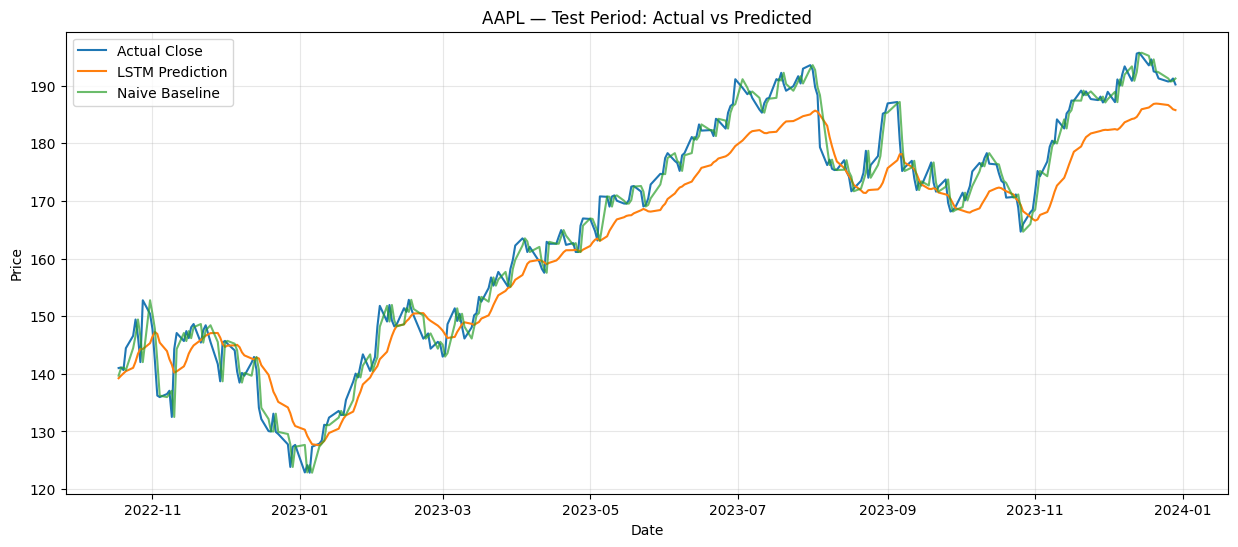

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(test_df["Date"], y_true, label="Actual Close")
plt.plot(test_df["Date"], y_pred, label="LSTM Prediction")
plt.plot(test_df["Date"], naive_pred, label="Naive Baseline", alpha=0.7)
plt.title(f"{TICKER.upper()} — Test Period: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

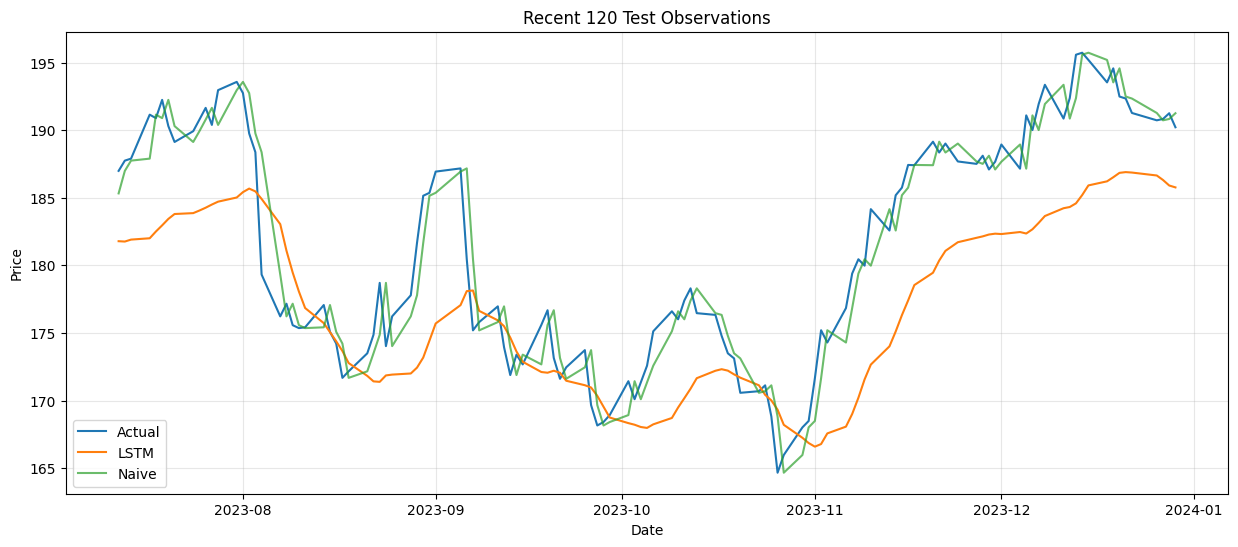

In [ ]:
N = min(120, len(y_true))
plt.figure(figsize=(15, 6))
plt.plot(test_df["Date"].iloc[-N:], y_true[-N:], label="Actual")
plt.plot(test_df["Date"].iloc[-N:], y_pred[-N:], label="LSTM")
plt.plot(test_df["Date"].iloc[-N:], naive_pred[-N:], label="Naive", alpha=0.7)
plt.title(f"Recent {N} Test Observations")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

,Date,Actual,Predicted,Naive,Absolute_Error,APE_%
217,2023-08-30,185.145874,173.179291,181.662994,11.966583,6.463327
175,2023-06-30,191.123459,179.528076,186.807724,11.595383,6.066959
268,2023-11-10,184.154846,172.659409,179.975830,11.495438,6.242268
219,2023-09-01,186.931732,175.697998,185.362946,11.233734,6.009539
290,2023-12-13,195.575607,184.584625,192.364777,10.990982,5.619812
218,2023-08-31,185.362961,174.431915,185.145874,10.931046,5.897104
12,2022-11-03,136.218628,146.912277,142.250763,10.693649,7.850357
291,2023-12-14,195.723816,185.197144,195.575607,10.526672,5.378330
265,2023-11-07,179.393692,169.006439,176.838257,10.387253,5.790200
266,2023-11-08,180.449448,170.205048,179.393692,10.244400,5.677158


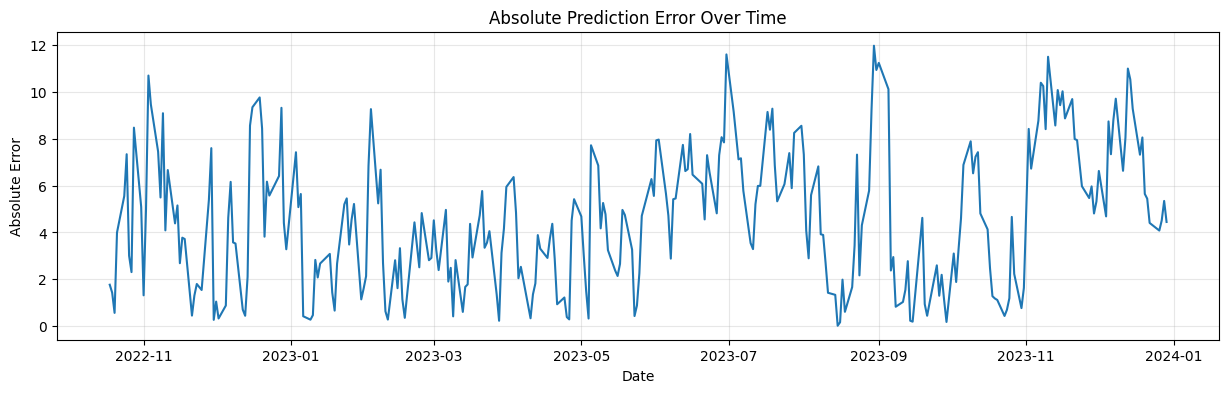

In [ ]:
results = pd.DataFrame({
    "Date": test_df["Date"].values,
    "Actual": y_true,
    "Predicted": y_pred,
    "Naive": naive_pred
})
results["Absolute_Error"] = np.abs(results["Actual"] - results["Predicted"])
results["APE_%"] = (results["Absolute_Error"] / results["Actual"] * 100)
display(results.sort_values("Absolute_Error", ascending=False).head(10))
plt.figure(figsize=(15, 4))
plt.plot(results["Date"], results["Absolute_Error"])
plt.title("Absolute Prediction Error Over Time")
plt.xlabel("Date")
plt.ylabel("Absolute Error")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
latest_raw = df[FEATURES].tail(LOOKBACK).values.astype("float32")
latest_scaled = feature_scaler.transform(latest_raw)
X_next = latest_scaled.reshape(1, LOOKBACK, len(FEATURES))
next_scaled = model.predict(X_next, verbose=0)
next_price = target_scaler.inverse_transform(next_scaled)[0, 0]
last_close = df["Close"].iloc[-1]
change = next_price - last_close
change_pct = (change / last_close) * 100
print(f"Last available close : ${last_close:.2f}")
print(f"Predicted next close : ${next_price:.2f}")
print(f"Predicted change      : ${change:+.2f} ({change_pct:+.2f}%)")

Last available close : $190.21
Predicted next close : $185.50
Predicted change      : $-4.71 (-2.48%)


In [ ]:
import joblib
save_dir = "."
MODEL_PATH = os.path.join(save_dir, f"{TICKER.lower()}_lstm.keras")
FEATURE_SCALER_PATH = os.path.join(save_dir, f"{TICKER.lower()}_feature_scaler.pkl")
TARGET_SCALER_PATH = os.path.join(save_dir, f"{TICKER.lower()}_target_scaler.pkl")
model.save(MODEL_PATH)
joblib.dump(feature_scaler, FEATURE_SCALER_PATH)
joblib.dump(target_scaler, TARGET_SCALER_PATH)
print("Saved:")
print(MODEL_PATH)
print(FEATURE_SCALER_PATH)
print(TARGET_SCALER_PATH)

Saved:
./aapl_lstm.keras
./aapl_feature_scaler.pkl
./aapl_target_scaler.pkl
